# 02 Muzzle-only Classification

这个 notebook 使用 `mouse_dataset/muzzle_crops` 里面已经裁剪好的 muzzle 图片来训练分类模型。  
核心逻辑和 full-image classification 相同，区别是：

- full image classification 读取 `mouse_dataset/images`
- muzzle-only classification 读取 `mouse_dataset/muzzle_crops`
- 只保留已经成功 crop 的图片

In [1]:
from pathlib import Path
import random

import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

In [2]:
# =========================
# Paths
# =========================
PROJECT_DIR = Path.cwd()
BASE_DIR = PROJECT_DIR / "mouse_dataset"

# Important: for muzzle-only classification, use cropped images here
IMG_DIR = BASE_DIR / "muzzle_crops"

MGS_CSV = BASE_DIR / "MouseGrimaceFaces_mgs.csv"
MAIN_CSV = BASE_DIR / "MouseGrimaceFaces_main.csv"

print("Current directory:", PROJECT_DIR)
print("Dataset path:", BASE_DIR)
print("MGS exists:", MGS_CSV.exists())
print("MAIN exists:", MAIN_CSV.exists())
print("Muzzle crop folder exists:", IMG_DIR.exists())
print("Number of crop images:", len(list(IMG_DIR.glob("*.jpg"))) + len(list(IMG_DIR.glob("*.png"))))

Current directory: /Users/baturu/Documents/Project_CV
Dataset path: /Users/baturu/Documents/Project_CV/mouse_dataset
MGS exists: True
MAIN exists: True
Muzzle crop folder exists: True
Number of crop images: 1592


In [3]:
# =========================
# Label construction
# =========================

def build_labels():
    df = pd.read_csv(MGS_CSV)
    main_df = pd.read_csv(MAIN_CSV)

    # Merge mouse identity information.
    # main_df has columns like: index, id, subset
    df = df.merge(
        main_df[["index", "id"]],
        on="index",
        how="left"
    )

    meta_cols = ["index", "subset", "id"]
    score_cols = [c for c in df.columns if c not in meta_cols]

    scores = df[score_cols].replace("-", np.nan)
    scores = scores.apply(pd.to_numeric, errors="coerce")

    # In this dataset, 9 means "cannot be judged".
    scores = scores.replace(9, np.nan)

    # Average all available MGS scores.
    df["mgs_mean"] = scores.mean(axis=1)

    # Remove images without valid MGS scores.
    df = df.dropna(subset=["mgs_mean"])

    # Binary label:
    # 0 = well-being / not impaired
    # 1 = impaired / pain-like expression
    df["label"] = (df["mgs_mean"] >= 1.0).astype(int)

    # For muzzle-only classification, image path points to crop folder.
    df["path"] = df["index"].apply(lambda x: IMG_DIR / str(x))

    before = len(df)

    # Keep only images that were successfully cropped.
    df = df[df["path"].apply(lambda p: p.exists())].copy()

    after = len(df)
    print(f"Rows before crop filtering: {before}")
    print(f"Rows after crop filtering:  {after}")
    print(f"Removed because crop image missing: {before - after}")

    return df[["index", "subset", "id", "path", "mgs_mean", "label"]].reset_index(drop=True)

In [5]:
# Build labels and inspect distribution

df = build_labels()

print("Total usable muzzle-crop images:", len(df))
print("Label distribution:")
print(df["label"].value_counts())

print("Subset distribution:")
print(df["subset"].value_counts())

df.head()

Rows before crop filtering: 3406
Rows after crop filtering:  1592
Removed because crop image missing: 1814
Total usable muzzle-crop images: 1592
Label distribution:
label
0    1264
1     328
Name: count, dtype: int64
Subset distribution:
subset
MR    594
KH    492
LW    365
AW     81
JW     60
Name: count, dtype: int64


,index,subset,id,path,mgs_mean,label
0,000008.jpg,KH,94,/Users/baturu/Documents/Project_CV/mouse_datas...,0.200000,0
1,000015.jpg,JW,202,/Users/baturu/Documents/Project_CV/mouse_datas...,0.533333,0
2,000031.jpg,KH,110,/Users/baturu/Documents/Project_CV/mouse_datas...,0.400000,0
3,000039.jpg,MR,2,/Users/baturu/Documents/Project_CV/mouse_datas...,1.300000,1
4,000056.jpg,KH,114,/Users/baturu/Documents/Project_CV/mouse_datas...,0.350000,0


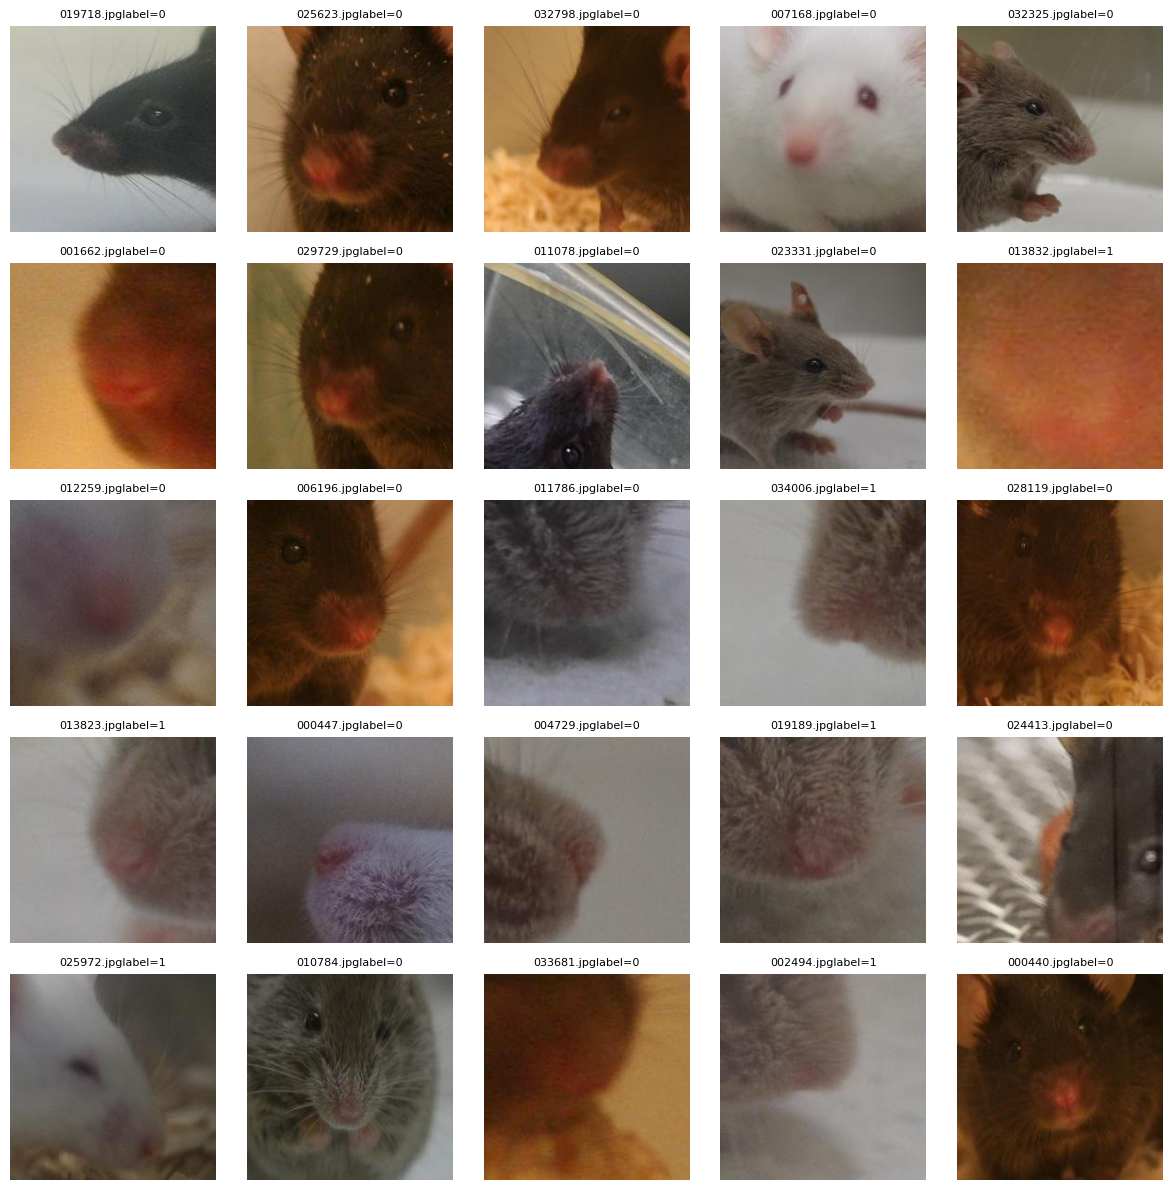

In [7]:
# Optional: visualize random muzzle crops before training

sample_df = df.sample(n=min(25, len(df)), random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img = Image.open(row["path"]).convert("RGB")
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f'{row["index"]}label={row["label"]}', fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# =========================
# Dataset
# =========================

class MouseDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["path"]).convert("RGB")

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(row["label"], dtype=torch.long)

        return img, label

In [10]:
# =========================
# Train / validation split
# =========================

# We split by mouse identity, not by individual image.
# This avoids putting images from the same mouse in both train and validation.

def make_group_split(df):
    groups = df["subset"].astype(str) + "_" + df["id"].astype(str)

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, val_idx = next(
        splitter.split(df, y=df["label"], groups=groups)
    )

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    return train_df, val_df

train_df, val_df = make_group_split(df)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))

print("Train label distribution:")
print(train_df["label"].value_counts())

print("Validation label distribution:")
print(val_df["label"].value_counts())

Train size: 1290
Validation size: 302
Train label distribution:
label
0    1037
1     253
Name: count, dtype: int64
Validation label distribution:
label
0    227
1     75
Name: count, dtype: int64


In [11]:
# =========================
# Transforms and dataloaders
# =========================

train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_ds = MouseDataset(train_df, transform=train_tfms)
val_ds = MouseDataset(val_df, transform=val_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [12]:
# =========================
# Device
# =========================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [13]:
# =========================
# Model
# =========================

model = models.convnext_tiny(
    weights=models.ConvNeXt_Tiny_Weights.DEFAULT
)

# Replace ImageNet classifier with binary classifier.
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    2
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [14]:
# =========================
# Training and evaluation functions
# =========================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0

    for imgs, labels in tqdm(loader, desc="Training"):
        imgs = imgs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Validation"):
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = outputs.argmax(dim=1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

In [16]:
# =========================
# Train
# =========================

EPOCHS = 10

history = []

for epoch in range(EPOCHS):
    print(f"Epoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    y_true, y_pred = evaluate(model, val_loader, device)

    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=["well-being", "impaired"],
        zero_division=0
    )

    print("Train loss:", train_loss)
    print("Confusion matrix:")
    print(cm)
    print("Classification report:")
    print(report)

    history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
    })

Epoch 1/10


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.81it/s]


Train loss: 0.0541829552001706
Confusion matrix:
[[210  17]
 [ 41  34]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.93      0.88       227
    impaired       0.67      0.45      0.54        75

    accuracy                           0.81       302
   macro avg       0.75      0.69      0.71       302
weighted avg       0.79      0.81      0.79       302

Epoch 2/10


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.84it/s]


Train loss: 0.0645982741900697
Confusion matrix:
[[213  14]
 [ 48  27]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.82      0.94      0.87       227
    impaired       0.66      0.36      0.47        75

    accuracy                           0.79       302
   macro avg       0.74      0.65      0.67       302
weighted avg       0.78      0.79      0.77       302

Epoch 3/10


...

Train loss: 0.0853696174340368
Confusion matrix:
[[211  16]
 [ 40  35]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.84      0.93      0.88       227
    impaired       0.69      0.47      0.56        75

    accuracy                           0.81       302
   macro avg       0.76      0.70      0.72       302
weighted avg       0.80      0.81      0.80       302

Epoch 9/10


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.88it/s]


Train loss: 0.0412461512051977
Confusion matrix:
[[214  13]
 [ 45  30]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.83      0.94      0.88       227
    impaired       0.70      0.40      0.51        75

    accuracy                           0.81       302
   macro avg       0.76      0.67      0.69       302
weighted avg       0.79      0.81      0.79       302

Epoch 10/10


Validation: 100%|██████████| 10/10 [00:05<00:00,  1.85it/s]

Train loss: 0.013639517656595605
Confusion matrix:
[[222   5]
 [ 52  23]]
Classification report:
              precision    recall  f1-score   support

  well-being       0.81      0.98      0.89       227
    impaired       0.82      0.31      0.45        75

    accuracy                           0.81       302
   macro avg       0.82      0.64      0.67       302
weighted avg       0.81      0.81      0.78       302



In [17]:
# =========================
# Save model
# =========================

SAVE_PATH = PROJECT_DIR / "mouse_wellbeing_muzzle_convnext_tiny.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_mapping": {
            0: "well-being",
            1: "impaired"
        },
        "image_dir": str(IMG_DIR),
        "note": "Muzzle-only classifier trained on DLC-cropped images."
    },
    SAVE_PATH
)

print("Saved model to:", SAVE_PATH)

Saved model to: /Users/baturu/Documents/Project_CV/mouse_wellbeing_muzzle_convnext_tiny.pt


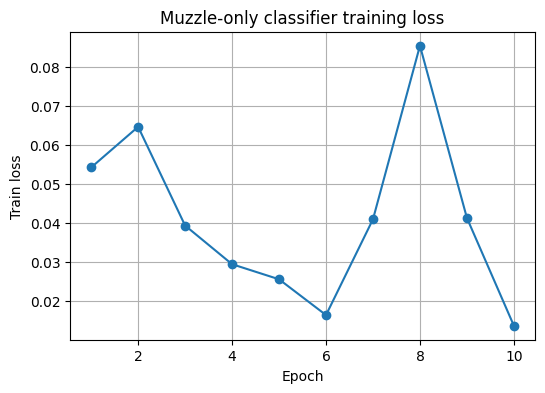

In [18]:
# Optional: plot training loss

history_df = pd.DataFrame(history)

plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Muzzle-only classifier training loss")
plt.grid(True)
plt.show()